# **DATA TRANSFORMATION & FEATURE ENGINEERING**

In [1]:
import pandas as pd
import numpy as np

energy_data = pd.read_csv("../Datasets/energy_data_sustainability.csv")
energy_data

,household_id,daily_energy_kwh,monthly_income_usd,region,device_type,timestamp,num_devices,household_size,green_awareness_score,energy_saving_level
0,1,5.97,1361.0,suburban,solar_monitor,2024-03-31,5,5,72.0,medium
1,2,3.94,2707.0,suburban,hybrid_system,2023-02-23,4,4,57.6,high
2,3,3.68,1239.0,rural,hybrid_system,2023-02-21,6,6,87.2,low
3,4,3.68,1327.0,urban,grid_meter,2023-05-28,3,7,11.2,medium
4,5,10.84,1993.0,suburban,hybrid_system,2023-06-09,1,10,15.0,medium
...,...,...,...,...,...,...,...,...,...,...
495,496,2.77,2690.0,rural,hybrid_system,2023-08-25,1,3,51.3,high
496,497,3.29,1363.0,suburban,hybrid_system,2024-02-29,9,8,56.4,medium
497,498,5.23,2087.0,suburban,solar_monitor,2023-08-09,5,2,43.8,medium
498,499,5.39,1105.0,suburban,solar_monitor,2023-03-09,3,4,94.6,high


In [2]:
energy_data['timestamp'] = pd.to_datetime(energy_data['timestamp'])

In [3]:
energy_data.describe()

,household_id,daily_energy_kwh,monthly_income_usd,timestamp,num_devices,household_size,green_awareness_score
count,500.000000,500.000000,500.000000,500,500.000000,500.000000,500.000000
mean,250.500000,4.965000,2005.618000,2023-08-06 14:29:45.600000,3.950000,3.974000,50.180000
min,1.000000,0.080000,200.000000,2023-01-03 00:00:00,1.000000,1.000000,3.600000
25%,125.750000,2.785000,1453.500000,2023-04-11 18:00:00,3.000000,3.000000,32.000000
50%,250.500000,4.380000,2016.500000,2023-08-01 12:00:00,4.000000,4.000000,50.850000
75%,375.250000,6.442500,2481.500000,2023-12-02 06:00:00,5.000000,5.000000,68.050000
max,500.000000,17.180000,4372.000000,2024-04-01 00:00:00,11.000000,10.000000,99.500000
std,144.481833,3.001835,755.247444,NaN,1.806107,1.724898,22.863022


DATA TRANSFORMATION
1. Normalitation (Min - Max)

In [4]:
# Before
energy_data['monthly_income_usd'].describe()

count     500.000000
mean     2005.618000
std       755.247444
min       200.000000
25%      1453.500000
50%      2016.500000
75%      2481.500000
max      4372.000000
Name: monthly_income_usd, dtype: float64

In [5]:
energy_data['monthly_income_norm'] = energy_data['monthly_income_usd'].transform(lambda x: (x - x.min())/(x.max() - x.min()))
# After
energy_data['monthly_income_norm'].describe()

count    500.000000
mean       0.432794
std        0.181028
min        0.000000
25%        0.300455
50%        0.435403
75%        0.546860
max        1.000000
Name: monthly_income_norm, dtype: float64

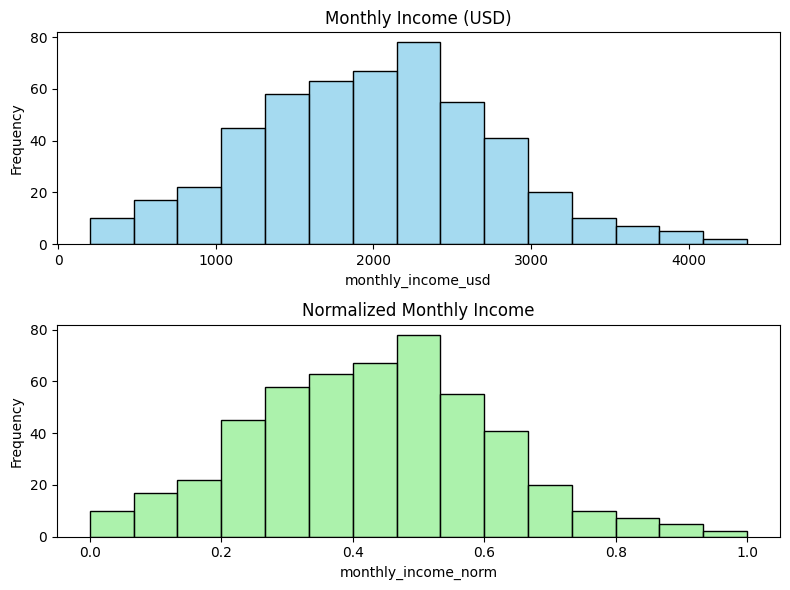

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

cols = ['monthly_income_usd', 'monthly_income_norm']
titles = ["Monthly Income (USD)", "Normalized Monthly Income"]
colors = ['skyblue', 'lightgreen']

fig, axes = plt.subplots(2, 1, figsize=(8, 6))

for ax, col, title, color in zip(axes, cols, titles, colors):
    sns.histplot(data=energy_data, x=col, bins=15, color=color, ax=ax)
    ax.set_title(title)
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

2. Standarization (Z-score)

In [7]:
# Before standarization: examine the distribution of the original variable
energy_data['daily_energy_kwh'].describe()

count    500.000000
mean       4.965000
std        3.001835
min        0.080000
25%        2.785000
50%        4.380000
75%        6.442500
max       17.180000
Name: daily_energy_kwh, dtype: float64

In [8]:
# Apply Z-score standardization
# This rescales the variable so that it has a mean of 0 and standard deviation of 1
from scipy.stats import zscore

energy_data['daily_energy_z'] = zscore(energy_data['daily_energy_kwh'])

# After standarization: check the result
energy_data['daily_energy_z'].describe().round(4)

count    500.0000
mean       0.0000
std        1.0010
min       -1.6290
25%       -0.7269
50%       -0.1951
75%        0.4927
max        4.0733
Name: daily_energy_z, dtype: float64

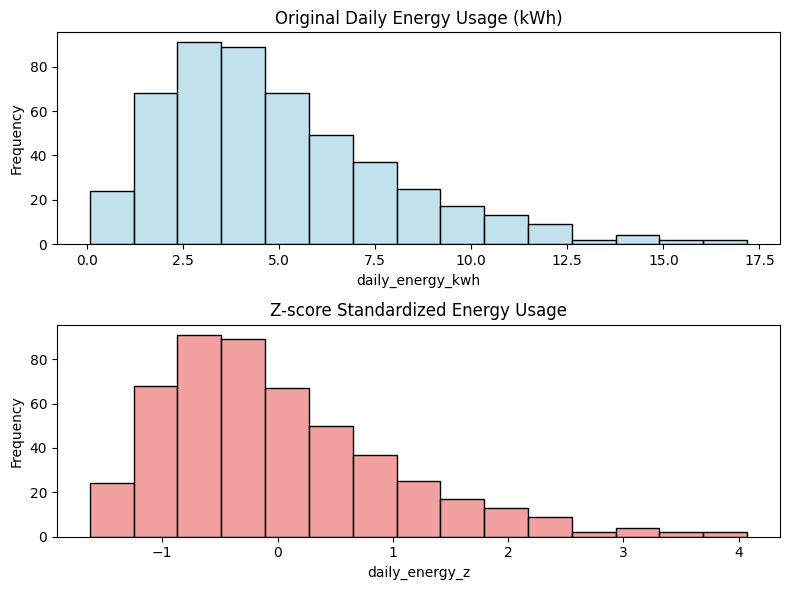

In [9]:
cols1 = ['daily_energy_kwh', 'daily_energy_z']
titles1 = ["Original Daily Energy Usage (kWh)", "Z-score Standardized Energy Usage"]
colors1 = ["lightblue", "lightcoral"]

fig, axes = plt.subplots(2, 1, figsize = (8,6))

for ax, col, title, color in zip(axes, cols1, titles1, colors1):
    sns.histplot(data=energy_data, x=col, bins=15, color=color, ax=ax)
    ax.set_title(title)
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

In [10]:
# Log transform daily_energy_kwh (add 1 to avoid log(0))
energy_data['log_energy_kwh'] = np.log1p(energy_data['daily_energy_kwh'])

# Square root transformation
energy_data['sqrt_energy_kwh'] = np.sqrt(energy_data['daily_energy_kwh'])

# Box-Cox transformation
from scipy.stats import boxcox
energy_data['boxcox_energy_kwh'], lambda_opt = boxcox(energy_data['daily_energy_kwh'])

print("Optimal lambda: ", lambda_opt)

Optimal lambda:  0.3218134461515229


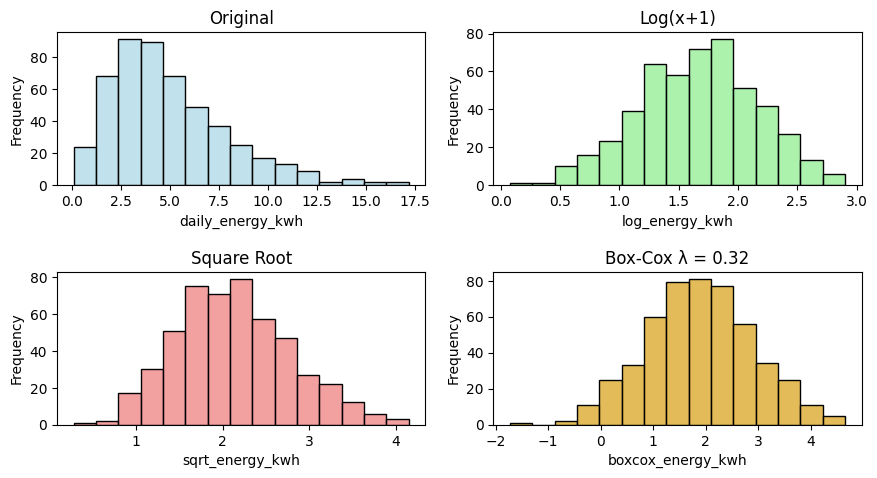

In [11]:
cols2 = ["daily_energy_kwh", "log_energy_kwh", "sqrt_energy_kwh", "boxcox_energy_kwh"]
titles2 = ["Original", "Log(x+1)", "Square Root", f"Box-Cox λ = {lambda_opt:.2f}"]
colors2 = ["lightblue", "lightgreen", "lightcoral", "goldenrod"]

fig, axes = plt.subplots(2, 2, figsize = (9,5))
axes = axes.flatten()

for ax, col, title, color in zip(axes, cols2, titles2, colors2):
    sns.histplot(data=energy_data, x=col, bins=15, color=color, ax=ax)
    ax.set_title(title)
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")

plt.tight_layout(pad=1.5)
plt.show()

In [12]:
energy_data.filter(like="energy").describe()

,daily_energy_kwh,daily_energy_z,log_energy_kwh,sqrt_energy_kwh,boxcox_energy_kwh
count,500.000000,5.000000e+02,500.000000,500.000000,500.000000
mean,4.965000,4.263256e-17,1.663964,2.128723,1.888730
std,3.001835,1.001002e+00,0.501305,0.659097,1.015569
min,0.080000,-1.628968e+00,0.076961,0.282843,-1.728926
25%,2.785000,-7.269497e-01,1.331043,1.668830,1.213230
50%,4.380000,-1.950760e-01,1.682687,2.092844,1.891004
75%,6.442500,4.926918e-01,2.007207,2.538208,2.551879
max,17.180000,4.073253e+00,2.900322,4.144876,4.652273


4. Encode categorical variables

In [13]:
# Display unique values for all character variables
y = energy_data.select_dtypes(include='object').columns

for col in y:
    print(f"\n{col}")
    print(energy_data[col].unique())


region
['suburban' 'rural' 'urban']

device_type
['solar_monitor' 'hybrid_system' 'grid_meter']

energy_saving_level
['medium' 'high' 'low']


In [14]:
# Label Encoding for energy_saving_level
levels = ['low', 'medium', 'high']

# Convert 'energy_saving_level' to an ordered factor with explicit levels
energy_data['energy_saving_level'] = pd.Categorical(energy_data['energy_saving_level'], 
                                                    categories=levels, ordered=True)

energy_data['energy_saving_encoded'] = energy_data['energy_saving_level'].cat.codes + 1

# Cross-check that encoding matches the factor levels
pd.crosstab(energy_data['energy_saving_level'], energy_data['energy_saving_encoded'])

energy_saving_encoded,1,2,3
energy_saving_level,,,
low,165,0,0
medium,0,249,0
high,0,0,86


In [15]:
# Create dummy variables for 'region' and keep all categories
dummies = pd.get_dummies(energy_data['region'], prefix='region')
energy_data = pd.concat([energy_data, dummies], axis=1)

# Check results: original region column + new dummy columns
energy_data[['household_id']].join(energy_data.filter(like='region')).head()

,household_id,region,region_rural,region_suburban,region_urban
0,1,suburban,False,True,False
1,2,suburban,False,True,False
2,3,rural,True,False,False
3,4,urban,False,False,True
4,5,suburban,False,True,False


In [16]:
# Check proportion of original categories (baseline)
energy_data["region"].value_counts(normalize=True)

region
suburban    0.424
urban       0.374
rural       0.202
Name: proportion, dtype: float64

In [17]:
# Check if dummy variables are correctly encoded by comparing means
energy_data.filter(like="region_").mean()

region_rural       0.202
region_suburban    0.424
region_urban       0.374
dtype: float64

### FEATURE ENGINEERING
Creating New Features

1. Ratios (e.g., income-per-person)

In [18]:
# Example: Create a ratio feature – income per person in the household
energy_data['income_per_person'] = energy_data['monthly_income_usd']/energy_data['household_size']

energy_data[['household_id', 'monthly_income_usd', 'household_size', 'income_per_person']]

,household_id,monthly_income_usd,household_size,income_per_person
0,1,1361.0,5,272.200000
1,2,2707.0,4,676.750000
2,3,1239.0,6,206.500000
3,4,1327.0,7,189.571429
4,5,1993.0,10,199.300000
...,...,...,...,...
495,496,2690.0,3,896.666667
496,497,1363.0,8,170.375000
497,498,2087.0,2,1043.500000
498,499,1105.0,4,276.250000


In [19]:
# Summary statistics of the new feature
energy_data['income_per_person'].describe()

count     500.000000
mean      637.896805
std       448.051112
min        23.555556
25%       335.475000
50%       526.857143
75%       794.000000
max      3225.000000
Name: income_per_person, dtype: float64

2. Time-Based Features

In [20]:
# Extract month (1–12) from the timestamp
# Extract weekday as a labeled factor (e.g., Mon, Tue, ...)
energy_data = energy_data.assign(
    month = energy_data['timestamp'].dt.month,
    weekday = energy_data['timestamp'].dt.day_name()
)

energy_data[['timestamp', 'month', 'weekday']]

,timestamp,month,weekday
0,2024-03-31,3,Sunday
1,2023-02-23,2,Thursday
2,2023-02-21,2,Tuesday
3,2023-05-28,5,Sunday
4,2023-06-09,6,Friday
...,...,...,...
495,2023-08-25,8,Friday
496,2024-02-29,2,Thursday
497,2023-08-09,8,Wednesday
498,2023-03-09,3,Thursday


In [21]:
# View distribution of data across months
energy_data['month'].value_counts().sort_index()

month
1     64
2     65
3     60
4     47
5     27
6     44
7     28
8     40
9     29
10    26
11    29
12    41
Name: count, dtype: int64

C:\Users\ASUS\AppData\Local\Temp\ipykernel_12360\1581867086.py:1: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='weekday', y='daily_energy_kwh', data=energy_data, estimator='mean', color='steelblue', ci=None)


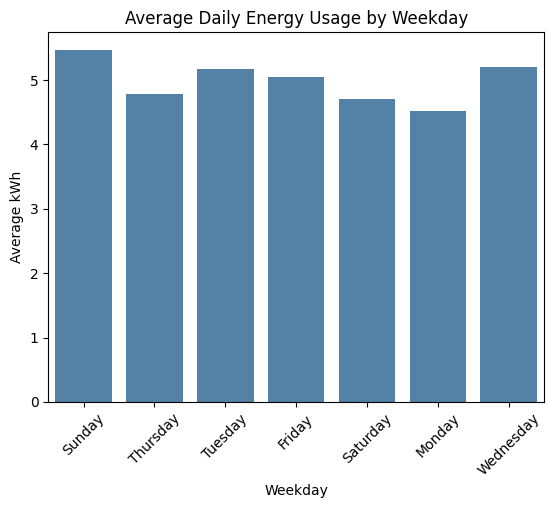

In [22]:
sns.barplot(x='weekday', y='daily_energy_kwh', data=energy_data, estimator='mean', color='steelblue', ci=None)
plt.title('Average Daily Energy Usage by Weekday')
plt.xlabel('Weekday')
plt.ylabel('Average kWh')
plt.xticks(rotation=45)
plt.show()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_12360\3228987548.py:1: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x=energy_data['month'].astype(str), y=energy_data['daily_energy_kwh'], estimator='mean', color='darkorange', ci=None,


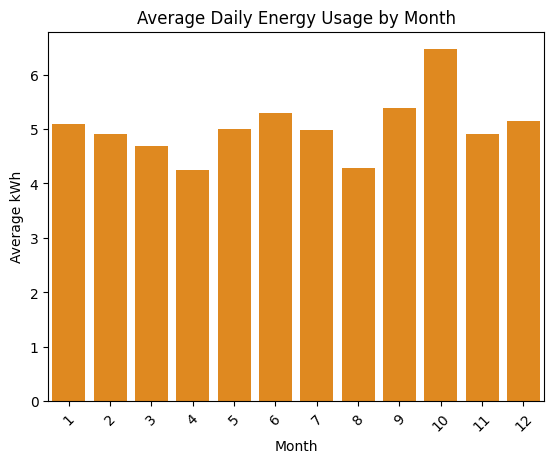

In [23]:
sns.barplot(x=energy_data['month'].astype(str), y=energy_data['daily_energy_kwh'], estimator='mean', color='darkorange', ci=None, 
            order=sorted(energy_data['month'].unique()))
plt.title('Average Daily Energy Usage by Month')
plt.xlabel('Month')
plt.ylabel('Average kWh')
plt.xticks(rotation=45)
plt.show()

3. Lag Feature

In [24]:
energy_data = energy_data.sort_values(['household_id','timestamp'])

energy_data['kwh_lag1'] = (energy_data.groupby('timestamp')['daily_energy_kwh'].shift(1))

In [25]:
energy_data[['household_id','timestamp','daily_energy_kwh','kwh_lag1']].sort_values(['timestamp','household_id'])

,household_id,timestamp,daily_energy_kwh,kwh_lag1
149,150,2023-01-03,1.58,NaN
342,343,2023-01-03,3.07,1.58
263,264,2023-01-04,7.80,NaN
312,313,2023-01-05,4.47,NaN
343,344,2023-01-06,8.16,NaN
...,...,...,...,...
0,1,2024-03-31,5.97,NaN
246,247,2024-03-31,13.67,5.97
291,292,2024-03-31,3.80,13.67
429,430,2024-03-31,2.77,3.80


In [77]:
import itertools
import random

np.random.seed(42)
x = [101, 102]
y = pd.date_range(start='2023-01-01', periods=10, freq='D')

toy_data = (
    pd.DataFrame(itertools.product(x, y), columns = ['household_id', 'date']).sort_values(['household_id','date']).reset_index(drop=True))
toy_data['daily_energy_kwh'] = np.random.uniform(3, 10, len(toy_data)).round(1)
toy_data['kwh_lag1'] = (toy_data.groupby('household_id')['daily_energy_kwh'].shift(1))

toy_data


,household_id,date,daily_energy_kwh,kwh_lag1
0,101,2023-01-01,5.6,NaN
1,101,2023-01-02,9.7,5.6
2,101,2023-01-03,8.1,9.7
3,101,2023-01-04,7.2,8.1
4,101,2023-01-05,4.1,7.2
5,101,2023-01-06,4.1,4.1
6,101,2023-01-07,3.4,4.1
7,101,2023-01-08,9.1,3.4
8,101,2023-01-09,7.2,9.1
9,101,2023-01-10,8.0,7.2


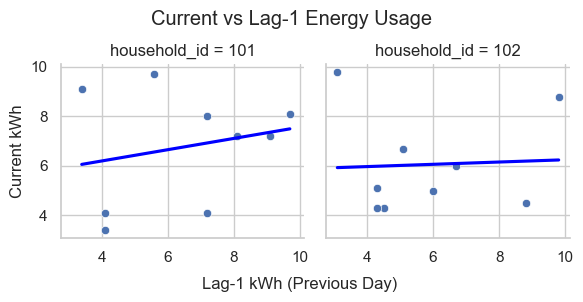

In [78]:
g = sns.FacetGrid(toy_data, col="household_id")

g.map_dataframe(sns.scatterplot, x="kwh_lag1", y="daily_energy_kwh")
g.map_dataframe(sns.regplot, x="kwh_lag1", y="daily_energy_kwh", ci=None, color="blue", scatter = False)

g.fig.suptitle("Current vs Lag-1 Energy Usage")
g.fig.subplots_adjust(top=0.8)

g.set_ylabels("Current kWh")
g.set_xlabels("")
g.fig.text(0.35, 0.05, "Lag-1 kWh (Previous Day)")
plt.show()

Binning Continuous Variables into Categories

**Example 1: Binning Energy Usage into Equal-Frequency Categories**

In [80]:
breaks = np.quantile(energy_data['daily_energy_kwh'], [0, 0.33, 0.66, 1])

energy_data['kwh_bin'] = pd.cut(energy_data['daily_energy_kwh'], 
                                bins=breaks, labels = ["Low", "Medium", "High"], include_lowest=True)

energy_data['kwh_bin'].value_counts().sort_index()

kwh_bin
Low       165
Medium    165
High      170
Name: count, dtype: int64

**Example 2: Binning Environmental Awareness Score (Custom Bins)**

In [81]:
energy_data['awareness_disc'] = pd.cut(energy_data['green_awareness_score'], [0, 40, 70, 100], 
                                       labels=['Low', 'Medium', 'High'])

energy_data['awareness_disc'].value_counts().sort_index()

awareness_disc
Low       182
Medium    205
High      113
Name: count, dtype: int64

**Example: Green Awareness Score Distribution by Energy Usage Level**

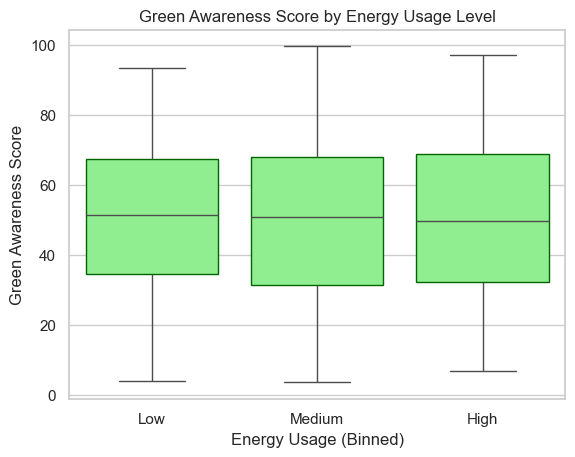

In [86]:
sns.boxplot(energy_data, x='kwh_bin', y='green_awareness_score', boxprops = dict(edgecolor='darkgreen', facecolor='lightgreen'))
plt.title("Green Awareness Score by Energy Usage Level")
plt.xlabel("Energy Usage (Binned)")
plt.ylabel("Green Awareness Score")
sns.set_theme(style='whitegrid')
plt.show()